In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [3]:
data = pd.read_csv("../../datasets/gapminder.csv")

In [4]:
data.columns

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='str')

Ejercicio: Realizar un gráfico de barras para visualizar gdpPercap en 2007 para Argentina, Brasil y Chile.

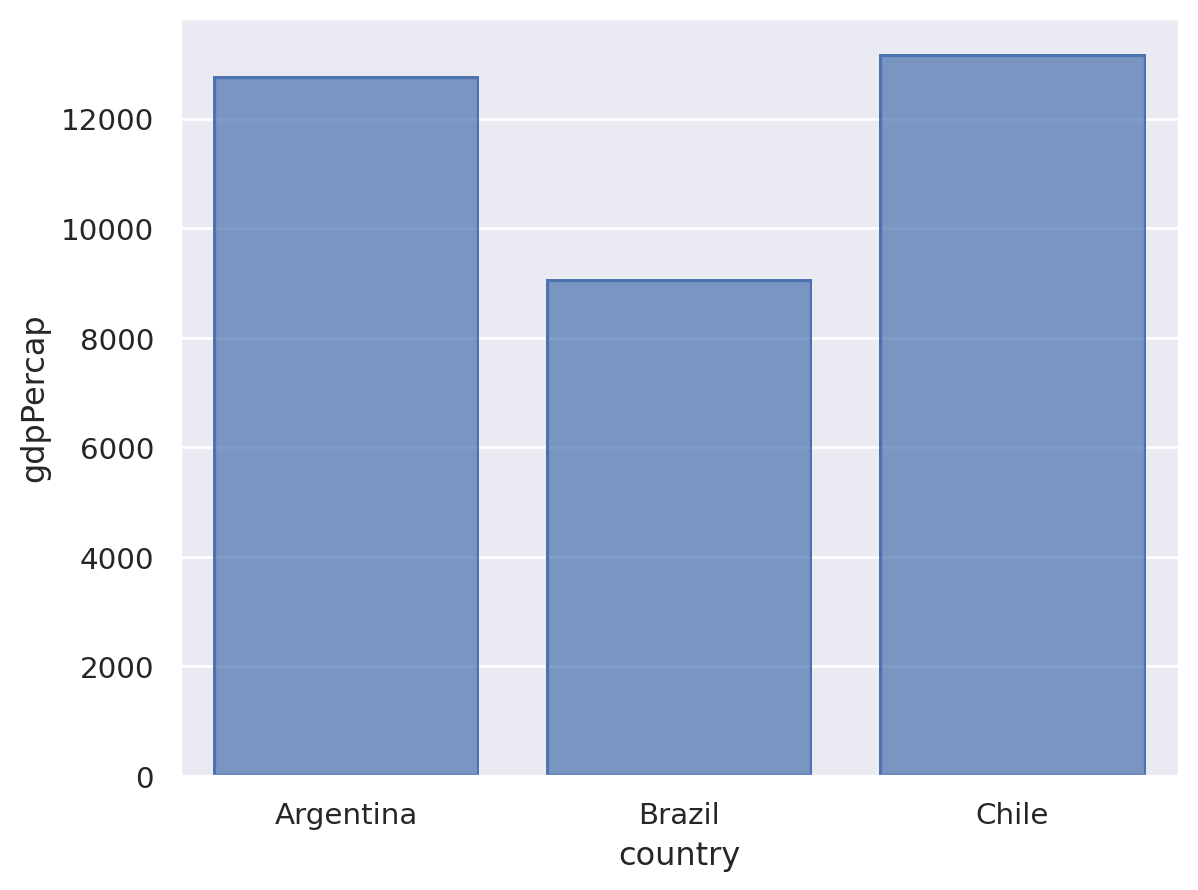

In [5]:
gdp2007 = data[data["year"] == 2007]
gdp2007_arg_bra_chi= gdp2007[gdp2007["country"].isin(['Argentina','Brazil','Chile']) ]

(
    so.Plot(data = gdp2007_arg_bra_chi, x = "country", y = "gdpPercap")
    .add(so.Bar())
)

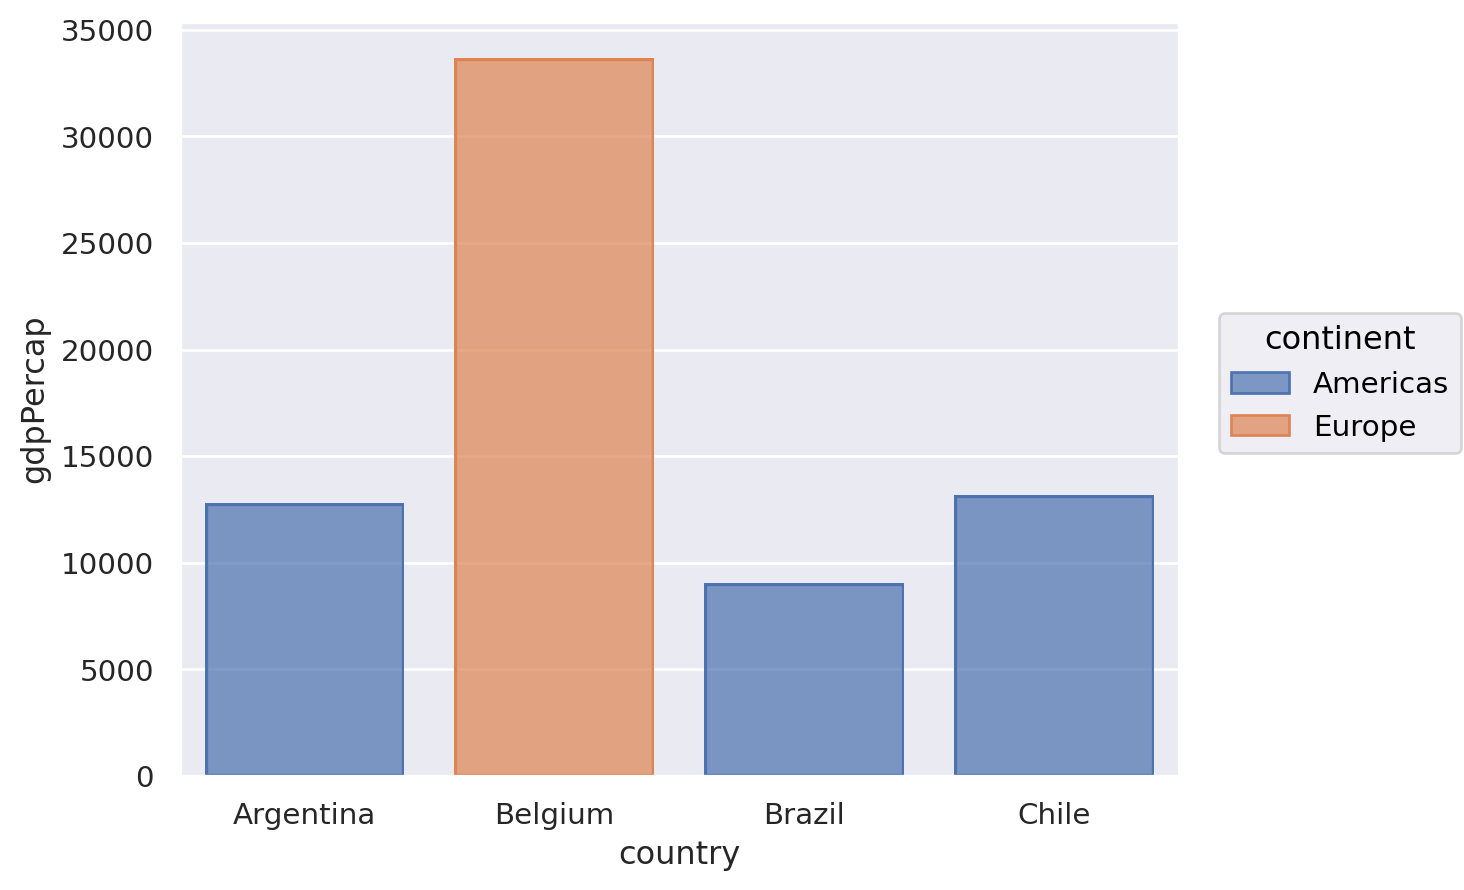

In [6]:
(
    so.Plot(
        data=data[(data["year"] == 2007) & (data["country"].isin(['Argentina', 'Brazil', 'Chile','Belgium']))], 
        x="country", 
        y="gdpPercap",
        color="continent"
    )
    .add(so.Bar())
)

Ejercicio: Realizar un gráfico de barras de cantidades de pingüinos en cada isla en el dataset de penguins de Seaborn, de las siguientes 2 formas:

1) Calcular los valores y graficarlos con Seaborn utilizando variables x e y apropiadas

2) Utilizar la función .hist() de SO

In [7]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [8]:
#1
penguins["species"].value_counts()


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [9]:
(penguins["species"]=="Adelie").sum()

np.int64(152)

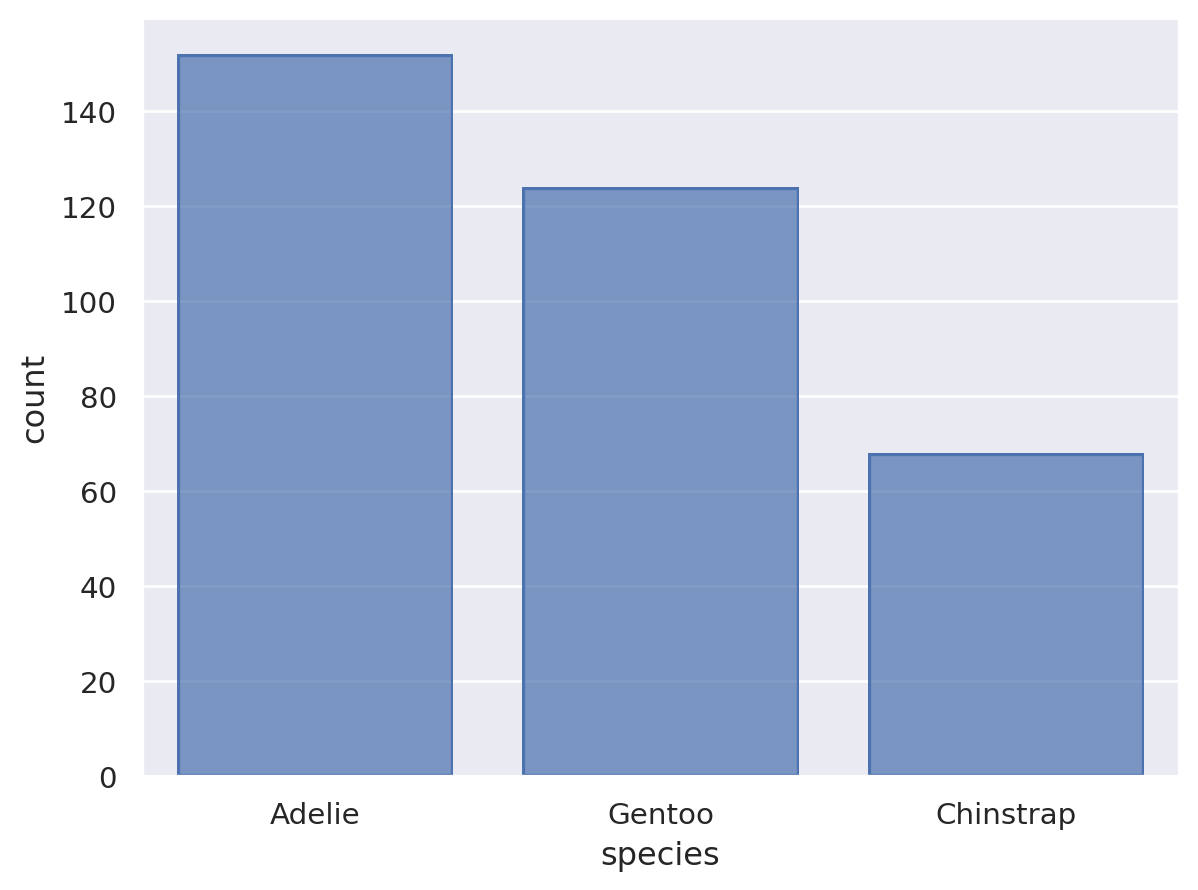

In [10]:
df_conteos = penguins["species"].value_counts().reset_index() 

(
    so.Plot(
        data=df_conteos, 
        x= "species", 
        y="count",
    )
    .add(so.Bar())
)

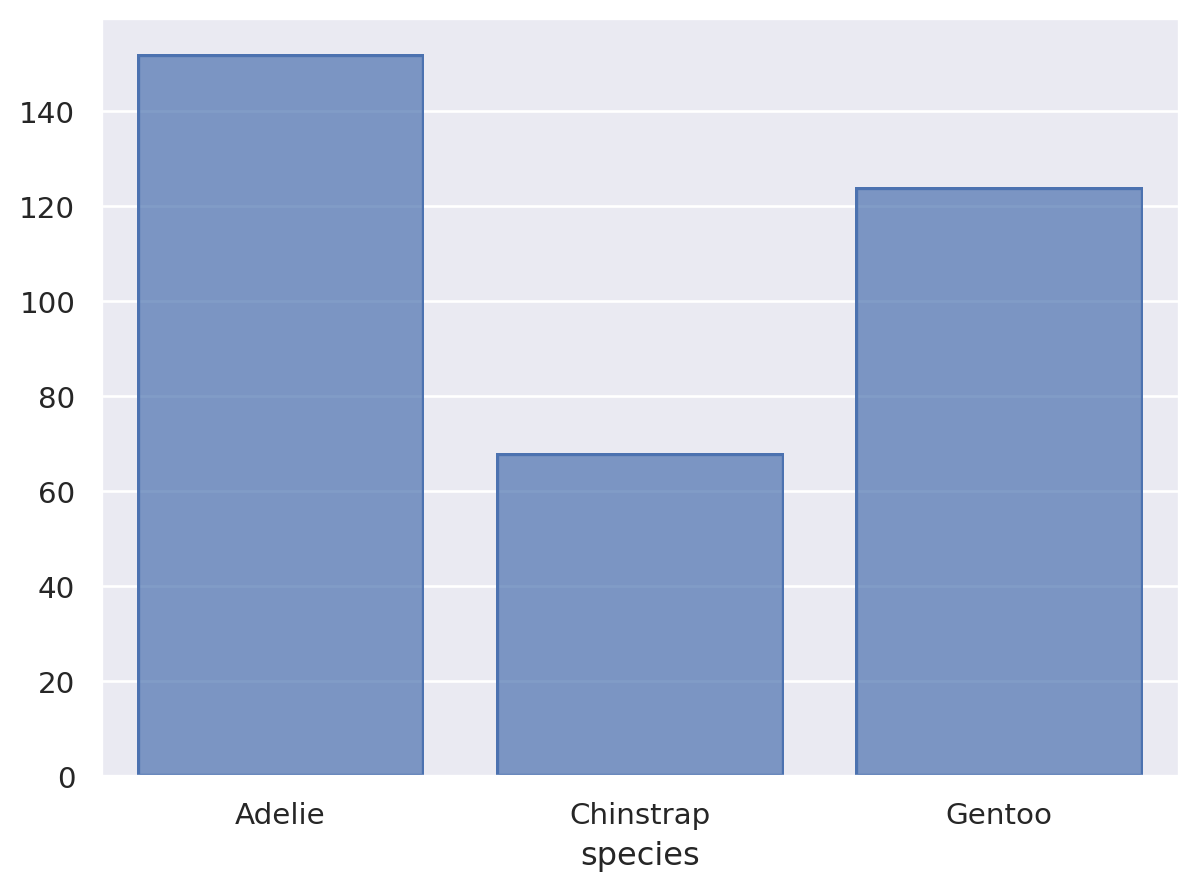

In [11]:
#2

(
    so.Plot(
        data=penguins,
        x="species"
    )
    .add(so.Bar(),so.Hist())
)

In [12]:
penguinsParcial = sns.load_dataset("penguins")

Escribir código que permita identificar cuántos datos faltantes hay en cada columna

In [13]:
penguinsParcial.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Escribir una línea de código que permita obtener un dataframe a partir de penguins con todas las siguientes modificaciones(en orden):
<ol>
<li>Eliminar la columna con más datos faltantes</li>
<li>Eliminar las filas con algún dato faltante</li>
<li>renombrar la columna species a species_name</li>
<li>resetear los índices (descartar los índices anteriores)</li>
</ol>

In [14]:
penguinsClean1 = penguinsParcial.drop(columns="sex")
penguinsClean1.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0


In [15]:
penguinsClean2= penguinsClean1.dropna()
penguinsClean2

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


In [16]:
penguinsClean3 = penguinsClean2.rename(columns={"species":"species_name"})
penguinsClean3

,species_name,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


In [20]:
penguinsClean4 =  penguinsClean3.reset_index()
penguinsClean4

penguinsClean5= penguinsClean4.drop(columns="index")

penguinsClean5

,species_name,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
337,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
338,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
339,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
340,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


In [22]:
penguinsParcialRes = penguinsParcial.drop(columns="sex").dropna().rename(columns={"species":"species_name"}).reset_index(drop=True)

penguinsParcialRes

,species_name,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
337,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
338,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
339,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
340,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


Pregunta 2

Ingresar un código ara generar el gráfico a partir de los datos de Gapminder, utilizando Seaborn Objects.

Usando el conjunto de datos Gapminder, escribir un código que calcule qué porcentaje de la población mundial correspondía a cada continente en el año 2007.

(Es un gráfico de líneas que muestra lifeExp por país de Argentina y Chile)

In [23]:
gapminder = pd.read_csv("../../datasets/gapminder.csv")

In [25]:
gapminder

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


In [38]:
# nos quedamos sólo con los datos de 2007

pop2007 = data[data["year"] == 2007]

poblacion_total = pop2007["pop"].sum()
poblacion_continentes = pop2007.groupby("continent")["pop"].sum()
poblacion_continentes

porcentajes_poblacion_por_continente = poblacion_continentes/poblacion_total

porcentajes_poblacion_por_continente * 100

continent
Africa      14.870224
Americas    14.379608
Asia        60.981376
Europe       9.376057
Oceania      0.392735
Name: pop, dtype: float64

Ejercicio 2

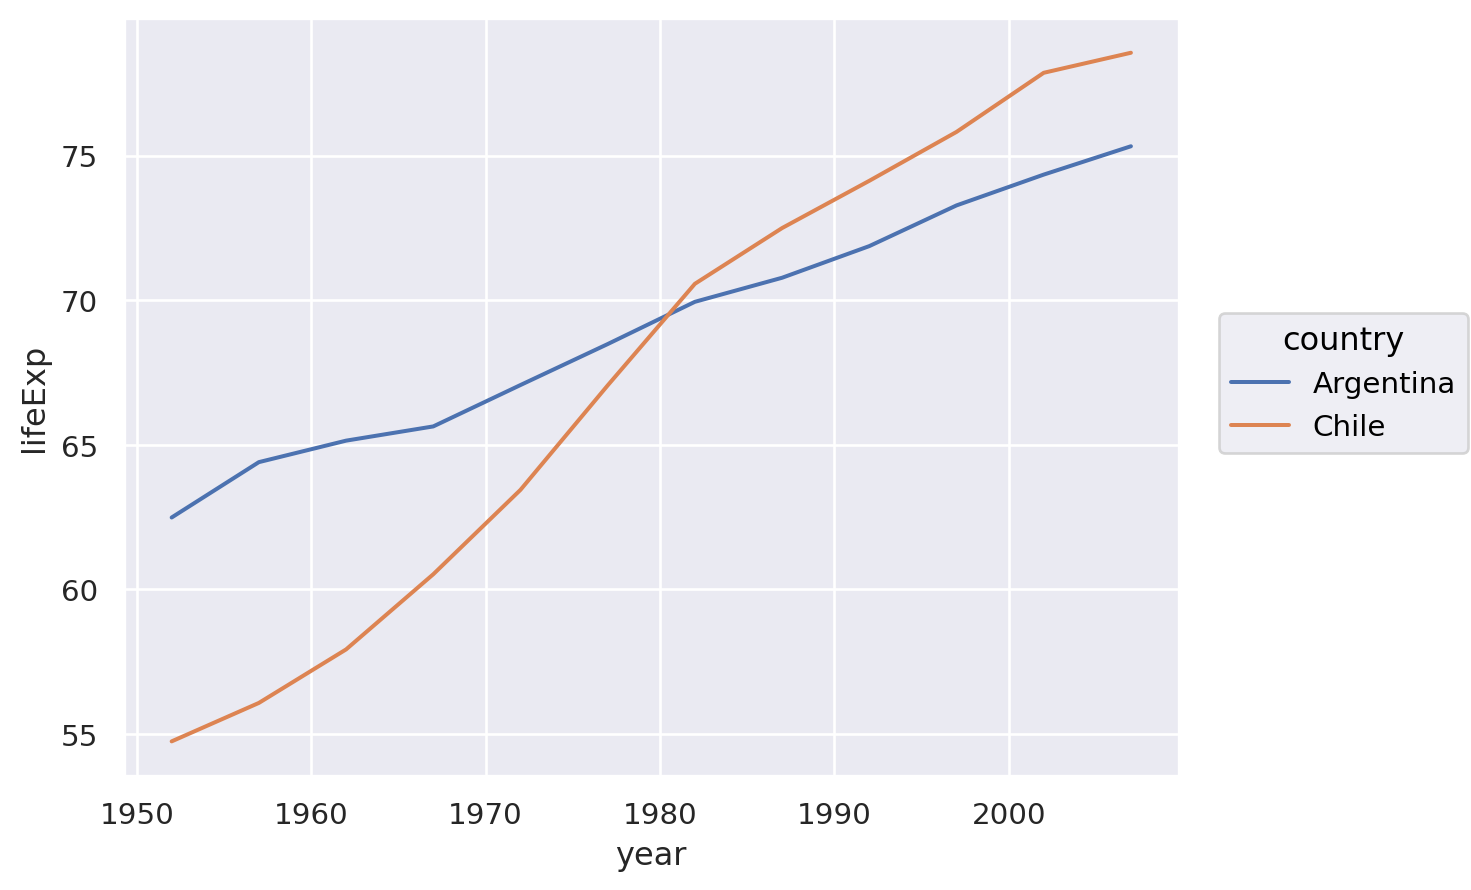

In [60]:
arg_chi = gapminder[gapminder["country"].isin(["Argentina","Chile"])]

(
    so.Plot(arg_chi, 'year','lifeExp',color='country')
    .add(so.Line())
)

A partir del dataset diamonds de seaborn:

Escribir código que permita :
<ol>
<li>Replicar el gráfico que se ve en el enunciado (con la misma cantidad de barras)</li>
<li>Calcular (mediante operaciones con los datos, no mediante la información del gráfico) el ancho de cada barra.</li>
</ol>

En la respuesta, escribir el código para ambos ítems e indicar el resultado obtenido para el ítem 2.

In [39]:
diamonds= sns.load_dataset('diamonds')
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


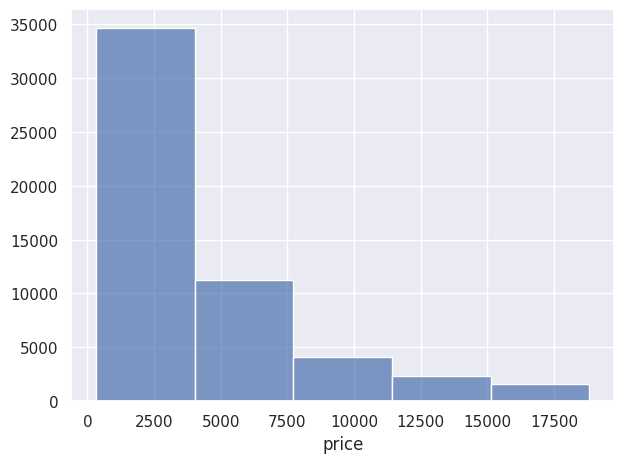

El ancho de cada barra será: $ 3699.4


In [57]:
(
    so.Plot(diamonds, x="price")
    .add(so.Bars(), so.Hist(bins=5))
    .show()
)
precio_max = diamonds["price"].max()
precio_min = diamonds["price"].min()

print("El ancho de cada barra será: $",(precio_max - precio_min)/5)